# Control integral

Vamos a tomar el sistema de otros ejemplos, pero esta vez vamos a tomar directamente un sistema con una entrada y una salida:

$$A_c =\begin{pmatrix}1&2&0 \\ -2&3&0\\ 1&0&-2\end{pmatrix}, \quad B = \begin{pmatrix}2\\ 1\\ -1\end{pmatrix}, \quad C_0 = (1\ 2\ 1)$$

In [1]:
import numpy as np
import control as ct
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

In [2]:
Ac = np.array([[1, 2, 0], [-2, 3, 0], [1, 0, -2]])
B  = np.array([[2], [1], [-1]])
Co = np.array([[1, 2, 1]])

rank_ctrb = np.linalg.matrix_rank(ct.ctrb(Ac, B))   # comprobamos que es controlable
rank_ctrb

3

## Control integral con acceso a los estados

Debemos construir una matriz ampliada para incluir el error entre la salida y el valor deseado en el sistema,

$$A_{mp} =\begin{pmatrix}A & 0 \\ C_2 & 0\end{pmatrix}, \quad B_{mp} =\begin{pmatrix}B \\ 0\end{pmatrix}$$

(Usamos en general $C_2$ ya que podemos ajustar la salida que queramos, no necesariamente la correspondiente a $C_0$, aunque sea ésta la que emplearemos en este ejemplo.) Y comprobamos que el par ampliado es controlable.

In [3]:
Amp = np.block([
    [Ac,          np.zeros((3, 1))],
    [Co,          np.zeros((1, 1))]
])
Bmp = np.vstack([B, [[0]]])

rank_ctrb_amp = np.linalg.matrix_rank(ct.ctrb(Amp, Bmp))
print('Amp =\n', Amp)
print('Bmp =\n', Bmp)
print('rank(ctrb(Amp,Bmp)) =', rank_ctrb_amp)

Amp =
 [[ 1.  2.  0.  0.]
 [-2.  3.  0.  0.]
 [ 1.  0. -2.  0.]
 [ 1.  2.  1.  0.]]
Bmp =
 [[ 2]
 [ 1]
 [-1]
 [ 0]]
rank(ctrb(Amp,Bmp)) = 4


Por tanto la ampliada es controlable. El sistema ampliado con el término de control integral quedaría,

$$\begin{pmatrix}\dot{x} \\ \dot e_i\end{pmatrix} = \begin{pmatrix}A -BK& -BK_I\\ C_2 & 0\end{pmatrix} \begin{pmatrix}x \\ e\end{pmatrix}+ \begin{pmatrix}0 \\ -I\end{pmatrix}y_d$$

Podemos emplear directamente `control.place` para colocar los autovalores del sistema y el del error.

In [4]:
lam = [-1, -2, -3, -4]   # el ultimo corresponde a la accion integral
K = ct.place(Amp, Bmp, lam)
K

array([[ 12.4615, -13.2308,  -0.3077,  -0.6154]])

Calculamos ahora la matriz con las realimentaciones. `K[:, :3]` son las tres primeras columnas (realimentación de estados), `K[:, 3:4]` es la cuarta columna (realimentación del error integral).

In [5]:
Ampr = np.block([
    [Ac - B @ K[:, :3],  -B @ K[:, 3:4]],
    [Co,                  np.zeros((1, 1))]
])
print('Ampr =\n', Ampr)
print('eig(Ampr) =', np.linalg.eigvals(Ampr))

Ampr =
 [[-23.9231  28.4615   0.6154   1.2308]
 [-14.4615  16.2308   0.3077   0.6154]
 [ 13.4615 -13.2308  -2.3077  -0.6154]
 [  1.       2.       1.       0.    ]]
eig(Ampr) = [-4. -3. -1. -2.]


Ahora nuestra única entrada es un valor de consigna que la salida debe seguir. Elegimos por ejemplo $y_d = 15$ y construimos una función adecuada para simular nuestro sistema (ver `sistema_lineal_I` al final del notebook).

In [6]:
def sistema_lineal_I(t, x, yd, A):
    """
    Sistema lineal en modo realimentacion con control integral.
    Anadimos la entrada al error, que corresponde a -yd, en la ultima
    componente del vector de estado ampliado.
    """
    n = A.shape[0]
    entrada = np.zeros(n)
    entrada[-1] = -yd
    return A @ x + entrada

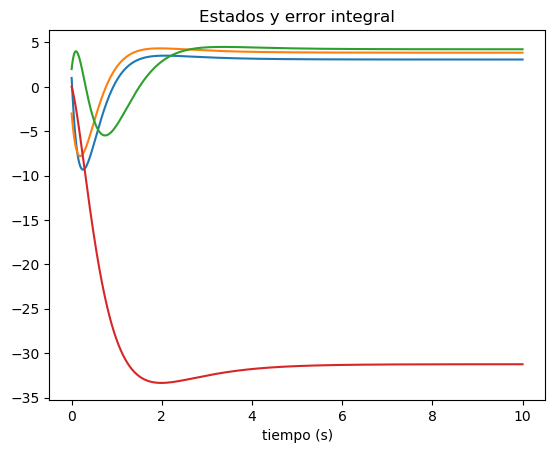

In [7]:
yd = 15
tf = 10
x0 = [1, -3, 2, 0]   # el cuarto valor corresponde al error

sol = solve_ivp(sistema_lineal_I, [0, tf], x0, args=(yd, Ampr), max_step=1e-2)

plt.figure(1)
plt.plot(sol.t, sol.y.T)
plt.xlabel('tiempo (s)')
plt.title('Estados y error integral')
plt.show()

Si representamos la salida,

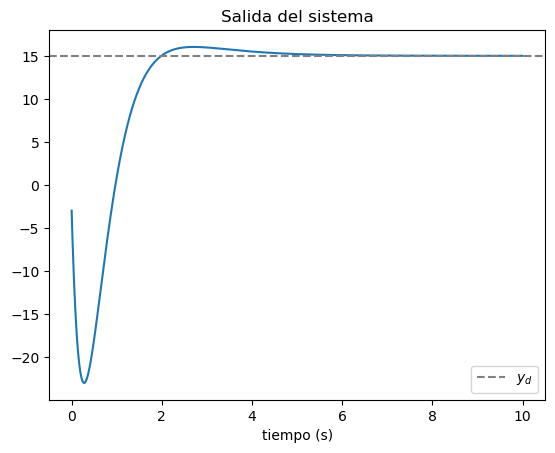

In [8]:
y_out = Co @ sol.y[:3, :]   # solo necesitamos los 3 primeros estados (x), no el error

plt.figure(2)
plt.plot(sol.t, y_out.T)
plt.axhline(yd, color='gray', linestyle='--', label='$y_d$')
plt.xlabel('tiempo (s)')
plt.title('Salida del sistema')
plt.legend()
plt.show()

La salida converge al valor de consigna $y_d=15$, gracias a la acción integral.

## Control integral sin acceso a los estados (con observador)

Supongamos ahora que no tenemos acceso a los estados. En ese caso, podríamos emplear un observador, siempre y cuando el sistema sea observable. Vamos a comprobarlo,

In [9]:
rank_obsv = np.linalg.matrix_rank(ct.obsv(Ac, Co))
rank_obsv

3

Como el rango es tres, nuestro sistema es observable.

Debemos ahora colocar los autovalores del observador de modo que sean algo más rápidos (parte real más a la izquierda) que los del controlador.

In [10]:
lamo = [-2, -3, -4]
Ko = ct.place(Ac.T, Co.T, lamo)
L = Ko.T
L

array([[-0.1667],
       [ 5.9167],
       [-0.6667]])

Ahora ya tenemos todos los ingredientes. Debemos construir una matriz ampliada que incluya tanto el observador como el error. Recordad que, por el **principio de separación**, no hace falta volver a comprobar la controlabilidad de la nueva matriz ampliada.

Pero, en realidad, no tenemos acceso a los estados para calcular el error integral: solo a sus estimas. Por tanto, la fila del error debe usar $\hat x$, no $x$,

$$\begin{pmatrix}\dot{x}\\ \dot{\hat{x}}\\ \dot{e}\end{pmatrix} = \begin{pmatrix}A & -BK &-BK_i\\ LC& A-BK-LC & -BK_i \\ 0 & C_2 &0\end{pmatrix}\begin{pmatrix}x\\ \hat{x}\\ e\end{pmatrix}+ \begin{pmatrix}0\\ 0\\ -y_d\end{pmatrix}$$

(la columna $C_2$ ahora está en la fila del $\hat x$, no del $x$).

In [11]:
K1 = K[:, :3]   # ganancia sobre los estados
K4 = K[:, 3:4]  # ganancia sobre el error integral

Ampo = np.block([
    [Ac,               -B @ K1,               -B @ K4],
    [L @ Co,            Ac - B @ K1 - L @ Co,  -B @ K4],
    [np.zeros((1, 3)),  Co,                     np.zeros((1, 1))]
])
print('Ampo shape:', Ampo.shape)
print('eig(Ampo) =', np.linalg.eigvals(Ampo))

Ampo shape: (7, 7)
eig(Ampo) = [-1. -4. -4. -2. -2. -3. -3.]


Construimos ahora una función para poder integrarla con `solve_ivp` (ver `sistema_lineal_IO` al final del notebook — es idéntica a `sistema_lineal_I`, solo cambia el nombre para distinguirla y reflejar que ahora incluye el observador, tal y como hace el `.mlx` original).

In [12]:
def sistema_lineal_IO(t, x, yd, A):
    """
    Igual que sistema_lineal_I, pero para el sistema ampliado con
    observador: [x, xhat, e].
    """
    n = A.shape[0]
    entrada = np.zeros(n)
    entrada[-1] = -yd
    return A @ x + entrada

Creamos un vector de estados iniciales que contenga los estados, los estimadores y el error.

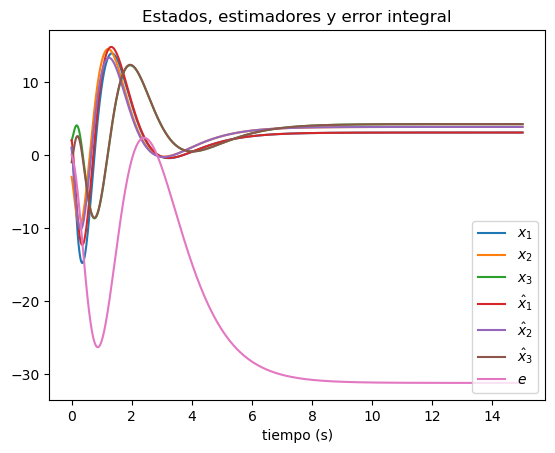

In [13]:
yd = 15
x0 = [1, -3, 2, 2, 1, -1, 0]
tf = 15   # le damos un poquito mas de tiempo...

sol = solve_ivp(sistema_lineal_IO, [0, tf], x0, args=(yd, Ampo), max_step=1e-2)

plt.figure(3)
plt.plot(sol.t, sol.y.T)
plt.xlabel('tiempo (s)')
plt.title('Estados, estimadores y error integral')
plt.legend([r'$x_1$', r'$x_2$', r'$x_3$', r'$\hat{x}_1$', r'$\hat{x}_2$', r'$\hat{x}_3$', '$e$'])
plt.show()

Pintamos las salidas,

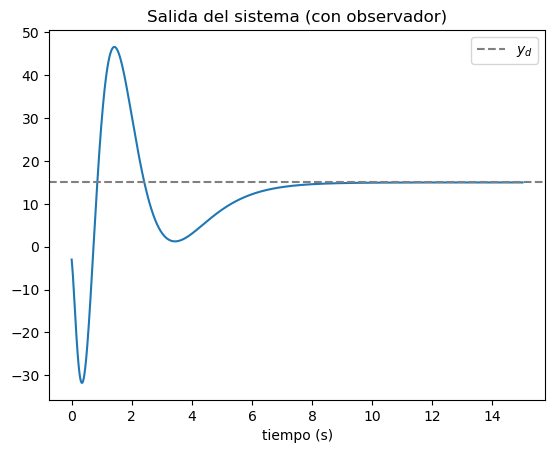

In [14]:
y_out = Co @ sol.y[:3, :]

plt.figure(4)
plt.plot(sol.t, y_out.T)
plt.axhline(yd, color='gray', linestyle='--', label='$y_d$')
plt.xlabel('tiempo (s)')
plt.title('Salida del sistema (con observador)')
plt.legend()
plt.show()

También aquí la salida termina convergiendo al valor de consigna $y_d=15$, incluso sin acceso directo a los estados.